# Shallow water, going further: your own closure in 2-D

The [first tutorial](simple_numpy.ipynb) used the shipped closures as-is. Here we
do the two things you actually need for research work:

1. **Write a new closure** — a bed-drag law of our own, as a `Closure` subclass.
2. **Make a child model** that composes it, and run it in **2-D**.

The point is that neither step edits the parent model. Physics enters by
*composition*; a new model is a subclass. No flags, no `if` branches, no
patching `SME`.

## 1. A closure of our own

A `Closure` declares two immutable class attributes — what it `closes`
(`bulk` / `bottom` / `surface` / `horizontal` / `interface`) and what fields it
`requires` — then supplies the physics.

We write a **Chézy-type quadratic bed drag**

$$\tau_b = \rho\, C_d\, u_b\,|u_b|$$

with a single parameter `C_d`. Zoomy already ships `RoughWall`, which is the
same family with `C_d` derived from a roughness height; writing it from scratch
here is the exercise.

Three methods matter:

- `register(m)` — declare the parameters. `m.parameter(name, default)` is
  register-or-query, so it is safe if the parent already declared it.
- `expression(s)` — the scalar 1-D form.
- `traction(s)` — the **vector** boundary traction in the local frame
  `{n, t_α}`. This is the one that matters in 2-D: the drag magnitude
  `|U_t|` couples the x and y components. A scalar-per-axis version would
  wrongly use `|u_i|` and under-predict the drag on diagonal flow.

In [1]:
import sympy as sp
from zoomy_core.model.models.closures import Closure


class ChezyBed(Closure):
    '''Quadratic Chezy bed drag:  tau_b = rho * C_d * u_b |u_b|.'''

    closes = "bottom"
    requires = ("u",)

    def register(self, m):
        m.parameter("C_d", 2.5e-3)          # register-or-query

    def expression(self, s):
        # scalar / 1-D form
        return s.par.rho * s.par.C_d * s.u * sp.Abs(s.u)

    def traction(self, s):
        # vector form: |U_t| couples the horizontal components
        speed = sp.sqrt(sum(ut ** 2 for ut in s.u_tangent))
        return {
            "normal": None,                  # pressure is the hydrostatic step's job
            "tangent": [s.par.rho * s.par.C_d * speed * ut for ut in s.u_tangent],
        }

## 2. A child model that uses it

Subclass the closest existing family and set a different closure list. That is
the whole pattern — `SME` is untouched and unaware.

In [2]:
from zoomy_core.model.models import SME, Newtonian, StressFree


class RoughChannelSME(SME):
    '''Shallow Moments with our own bed drag in place of the stock slip law.'''

    def __init__(self, **kw):
        kw.setdefault("closures", [Newtonian(), ChezyBed(), StressFree()])
        super().__init__(**kw)

## 3. Build it in 2-D

Mind the `dimension` convention: for `SME` it counts the **vertical too**, so
`dimension=3` means *two* horizontal directions — a 2-D depth-averaged model.
`level=1` keeps one vertical velocity moment beyond the depth average.

Four wall tags this time, and a 2-D Riemann problem for the initial state.

In [3]:
import numpy as np
import zoomy_core.model.boundary_conditions as BC
import zoomy_core.model.initial_conditions as IC

model = RoughChannelSME(
    level=1,
    dimension=3,                                  # 2 horizontal directions
    boundary_conditions=BC.BoundaryConditions([
        BC.Wall(tag=t) for t in ("left", "right", "bottom", "top")
    ]),
    initial_conditions=IC.RP2d(
        high=lambda n: np.array([0.0, 2.0] + [0.0] * (n - 2)),
        low=lambda n: np.array([0.0, 1.0] + [0.0] * (n - 2)),
        jump_position_x=0.5, jump_position_y=0.5,
    ),
)

print("closures:", [type(c).__name__ for c in model.closures])

closures: ['Newtonian', 'ChezyBed', 'StressFree']


In [4]:
from zoomy_core.systemmodel import SystemModel

sm = SystemModel.from_model(model)

print("state       :", [str(s) for s in sm.state])
print("equations   :", sm.n_equations, " spatial dims:", sm.n_dim)
print("flux shape  :", sm.flux.shape)
print("NCP shape   :", sm.nonconservative_matrix.shape)
print("our C_d     :", sm.parameter_values.C_d)

SystemModel cache DISABLED for __main__.RoughChannelSME: cannot read the source of __main__.RoughChannelSME (REPL/exec-defined?). Deriving fresh every call — a source we cannot fingerprint could otherwise be served stale after an edit (REQ-188).


state       : ['b', 'h', 'q_x_0', 'q_x_1', 'q_y_0', 'q_y_1']
equations   : 6  spatial dims: 2
flux shape  : (6, 2)
NCP shape   : (6, 6, 2)
our C_d     : 0.0025


The state is `[b, h, q_x_0, q_x_1, q_y_0, q_y_1]` — bed, depth, and two moments
per horizontal direction. `C_d` shows up in `parameter_values` because our
closure's `register` ran during the derivation.

```{note}
Closure parameters are registered **during derivation**, not at construction.
`model.parameter_values.C_d` does not exist until the model has been derived —
read it off the `SystemModel`, as above.
```

## 4. Solve

In [5]:
from zoomy_core.numerics import NumericalSystemModel, ReconstructionSpec
from zoomy_core.mesh import BaseMesh
from zoomy_core.fvm.solver_numpy import HyperbolicSolver
from zoomy_core.fvm import timestepping

sm.aux_initial_conditions = IC.Constant(constants=lambda n: np.zeros(n))
nsm = NumericalSystemModel.from_system_model(
    sm, reconstruction=ReconstructionSpec(order=1))

mesh = BaseMesh.create_2d(domain=(0.0, 1.0, 0.0, 1.0), nx=24, ny=24)
solver = HyperbolicSolver(time_end=0.05,
                          compute_dt=timestepping.adaptive(CFL=0.45))
Q, _ = solver.solve(mesh, nsm, write_output=False)

n = mesh.n_inner_cells
Q = np.asarray(Q[:, :n], dtype=float)
b, h = Q[0], Q[1]
print(f"h range : {h.min():.5f} .. {h.max():.5f}")
print(f"finite  : {np.isfinite(Q).all()}")

2026-07-22 17:02:18.037 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 10, time: 0.019993, dt: 0.001925, next write at time: 0.050000


2026-07-22 17:02:18.409 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 20, time: 0.038913, dt: 0.001872, next write at time: 0.050000


2026-07-22 17:02:18.632 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1295 - Finished simulation with in 0.966 seconds


h range : 1.00000 .. 1.99710
finite  : True


### Mass check

Closed box again, so mass is conserved exactly. The high quadrant is a quarter of
the 24x24 domain: `144*2 + 432*1 = 720`.

In [6]:
expected = 720.0
error = abs(h.sum() - expected)
print(f"mass = {h.sum():.9f}   error = {error:.3e}")
assert error < 1e-8, "wall boundaries are leaking mass"

mass = 720.000000000   error = 0.000e+00


## 5. Look at it

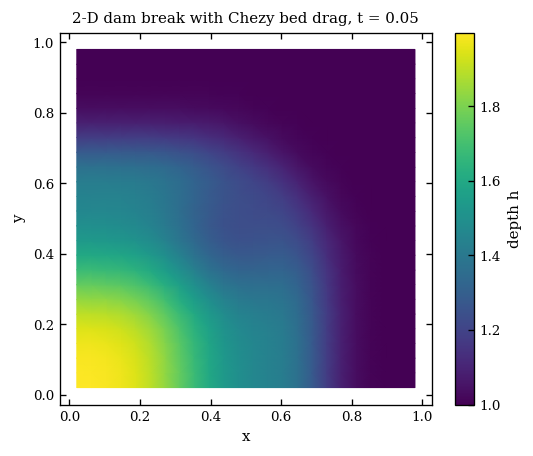

In [7]:
import matplotlib.pyplot as plt
import zoomy_plotting as zp

centers = mesh.cell_centers_computed()
x, y = centers[0][:n], centers[1][:n]

with zp.apply_style():
    fig, ax = plt.subplots(figsize=(4.6, 3.8))
    tpc = ax.tripcolor(x, y, h, shading="gouraud", cmap=zp.CMAP_CONTINUOUS)
    fig.colorbar(tpc, ax=ax, label="depth h")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"2-D dam break with Chezy bed drag, t = {solver.time_end}")
    ax.set_aspect("equal")
    fig.tight_layout()

## Does the drag actually do anything?

A closure you cannot see is a closure you cannot trust. Sweep `C_d` and measure
the depth-averaged kinetic energy: it must fall **monotonically** with drag. One
data point could be noise; a monotone trend over three cannot be.

This runs three 2-D solves to `t = 0.4`, so it takes a minute or two.

In [8]:
def run(C_d, time_end=0.4):
    m = RoughChannelSME(
        level=1, dimension=3,
        boundary_conditions=BC.BoundaryConditions(
            [BC.Wall(tag=t) for t in ("left", "right", "bottom", "top")]),
        initial_conditions=IC.RP2d(
            high=lambda k: np.array([0.0, 2.0] + [0.0] * (k - 2)),
            low=lambda k: np.array([0.0, 1.0] + [0.0] * (k - 2)),
            jump_position_x=0.5, jump_position_y=0.5),
    )
    s = SystemModel.from_model(m)
    s.parameter_values.C_d = C_d
    s.aux_initial_conditions = IC.Constant(constants=lambda k: np.zeros(k))
    nn = NumericalSystemModel.from_system_model(
        s, reconstruction=ReconstructionSpec(order=1))
    msh = BaseMesh.create_2d(domain=(0.0, 1.0, 0.0, 1.0), nx=24, ny=24)
    sol = HyperbolicSolver(time_end=time_end,
                           compute_dt=timestepping.adaptive(CFL=0.45))
    QQ, _ = sol.solve(msh, nn, write_output=False)
    QQ = np.asarray(QQ[:, :msh.n_inner_cells], dtype=float)
    hh, qx0, qy0 = QQ[1], QQ[2], QQ[4]
    return float(np.sum((qx0 ** 2 + qy0 ** 2) / np.maximum(hh, 1e-12)))


ke = {C_d: run(C_d) for C_d in (0.0, 5e-2, 2e-1)}
base = ke[0.0]
for C_d, val in ke.items():
    print(f"C_d = {C_d:<6}  KE = {val:9.4f}   ({100 * (1 - val / base):5.2f} % below frictionless)")

assert ke[0.0] > ke[5e-2] > ke[2e-1], "kinetic energy must fall monotonically with drag"

2026-07-22 17:02:26.171 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 10, time: 0.019993, dt: 0.001925, next write at time: 0.400000


2026-07-22 17:02:26.544 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 20, time: 0.038913, dt: 0.001872, next write at time: 0.400000


2026-07-22 17:02:26.916 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 30, time: 0.057549, dt: 0.001859, next write at time: 0.400000


2026-07-22 17:02:27.288 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 40, time: 0.076126, dt: 0.001860, next write at time: 0.400000


2026-07-22 17:02:27.659 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 50, time: 0.094806, dt: 0.001878, next write at time: 0.400000


...

2026-07-22 17:03:00.121 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 170, time: 0.345537, dt: 0.002175, next write at time: 0.400000


2026-07-22 17:03:00.493 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 180, time: 0.367218, dt: 0.002165, next write at time: 0.400000


2026-07-22 17:03:00.864 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 190, time: 0.388860, dt: 0.002166, next write at time: 0.400000


2026-07-22 17:03:01.087 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1295 - Finished simulation with in 7.270 seconds


C_d = 0.0     KE =  341.4431   ( 0.00 % below frictionless)
C_d = 0.05    KE =  337.0346   ( 1.29 % below frictionless)
C_d = 0.2     KE =  324.6014   ( 4.93 % below frictionless)


That is the whole extension story: a `Closure` subclass, a model subclass that
composes it, and a measurement showing it does what it claims.

Next: the same model on a different backend — see
[Backends](../../../backends/index.md). The model definition does not change.